In [2]:
%%bash
curl -L -o telco-customer-churn.zip \
  https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  171k  100  171k    0     0   300k      0 --:--:-- --:--:-- --:--:--  300k


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection  import train_test_split
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Dropout

In [4]:
!unzip /content/telco-customer-churn.zip

Archive:  /content/telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [5]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df.drop('customerID',axis = 1,inplace = True)

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors = 'coerce')

In [13]:
print(df.nunique())

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


In [14]:
cat_cols = [col for col in df.columns if df[col].dtype in ['category','bool','object']]
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [15]:
num_cols = [col for col in df.columns if df[col].dtype in ['int64','float64']]
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

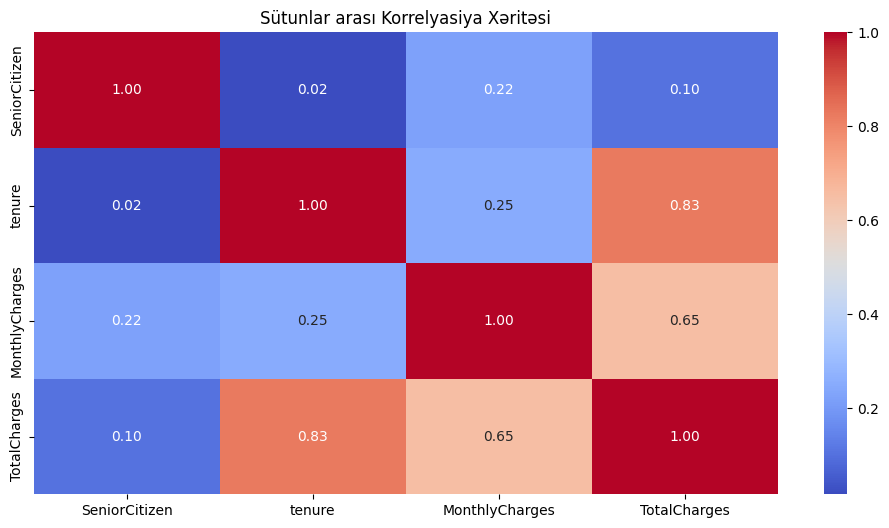

In [16]:
plt.figure(figsize= (12,6))
sns.heatmap(df.corr(numeric_only = True),annot = True,fmt = '.2f',cmap = 'coolwarm')
plt.title('Sütunlar arası Korrelyasiya Xəritəsi')
plt.show()

In [17]:
df.drop('TotalCharges', axis=1, inplace=True)


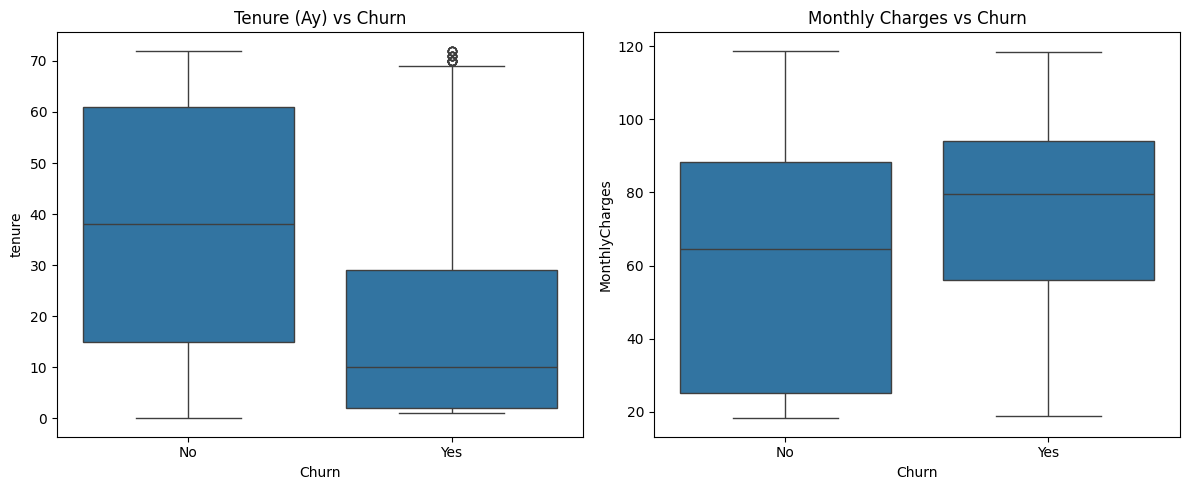

In [18]:

plt.figure(figsize=(12, 5))

# 1. Tenure vs Churn
plt.subplot(1, 2, 1)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure (Ay) vs Churn')

# 2. MonthlyCharges vs Churn
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

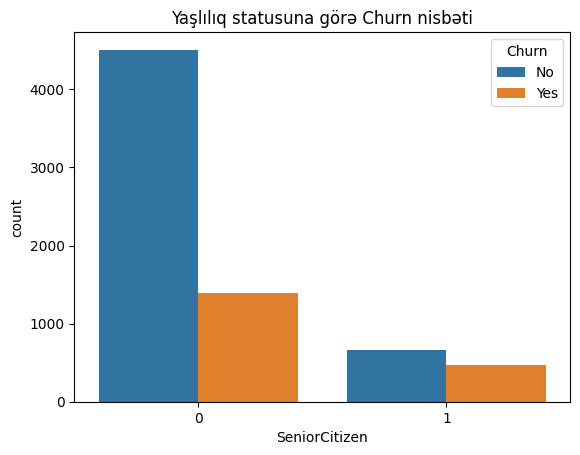

In [19]:
# SeniorCitizen üçün daha düzgün qrafik
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Yaşlılıq statusuna görə Churn nisbəti')
plt.show()

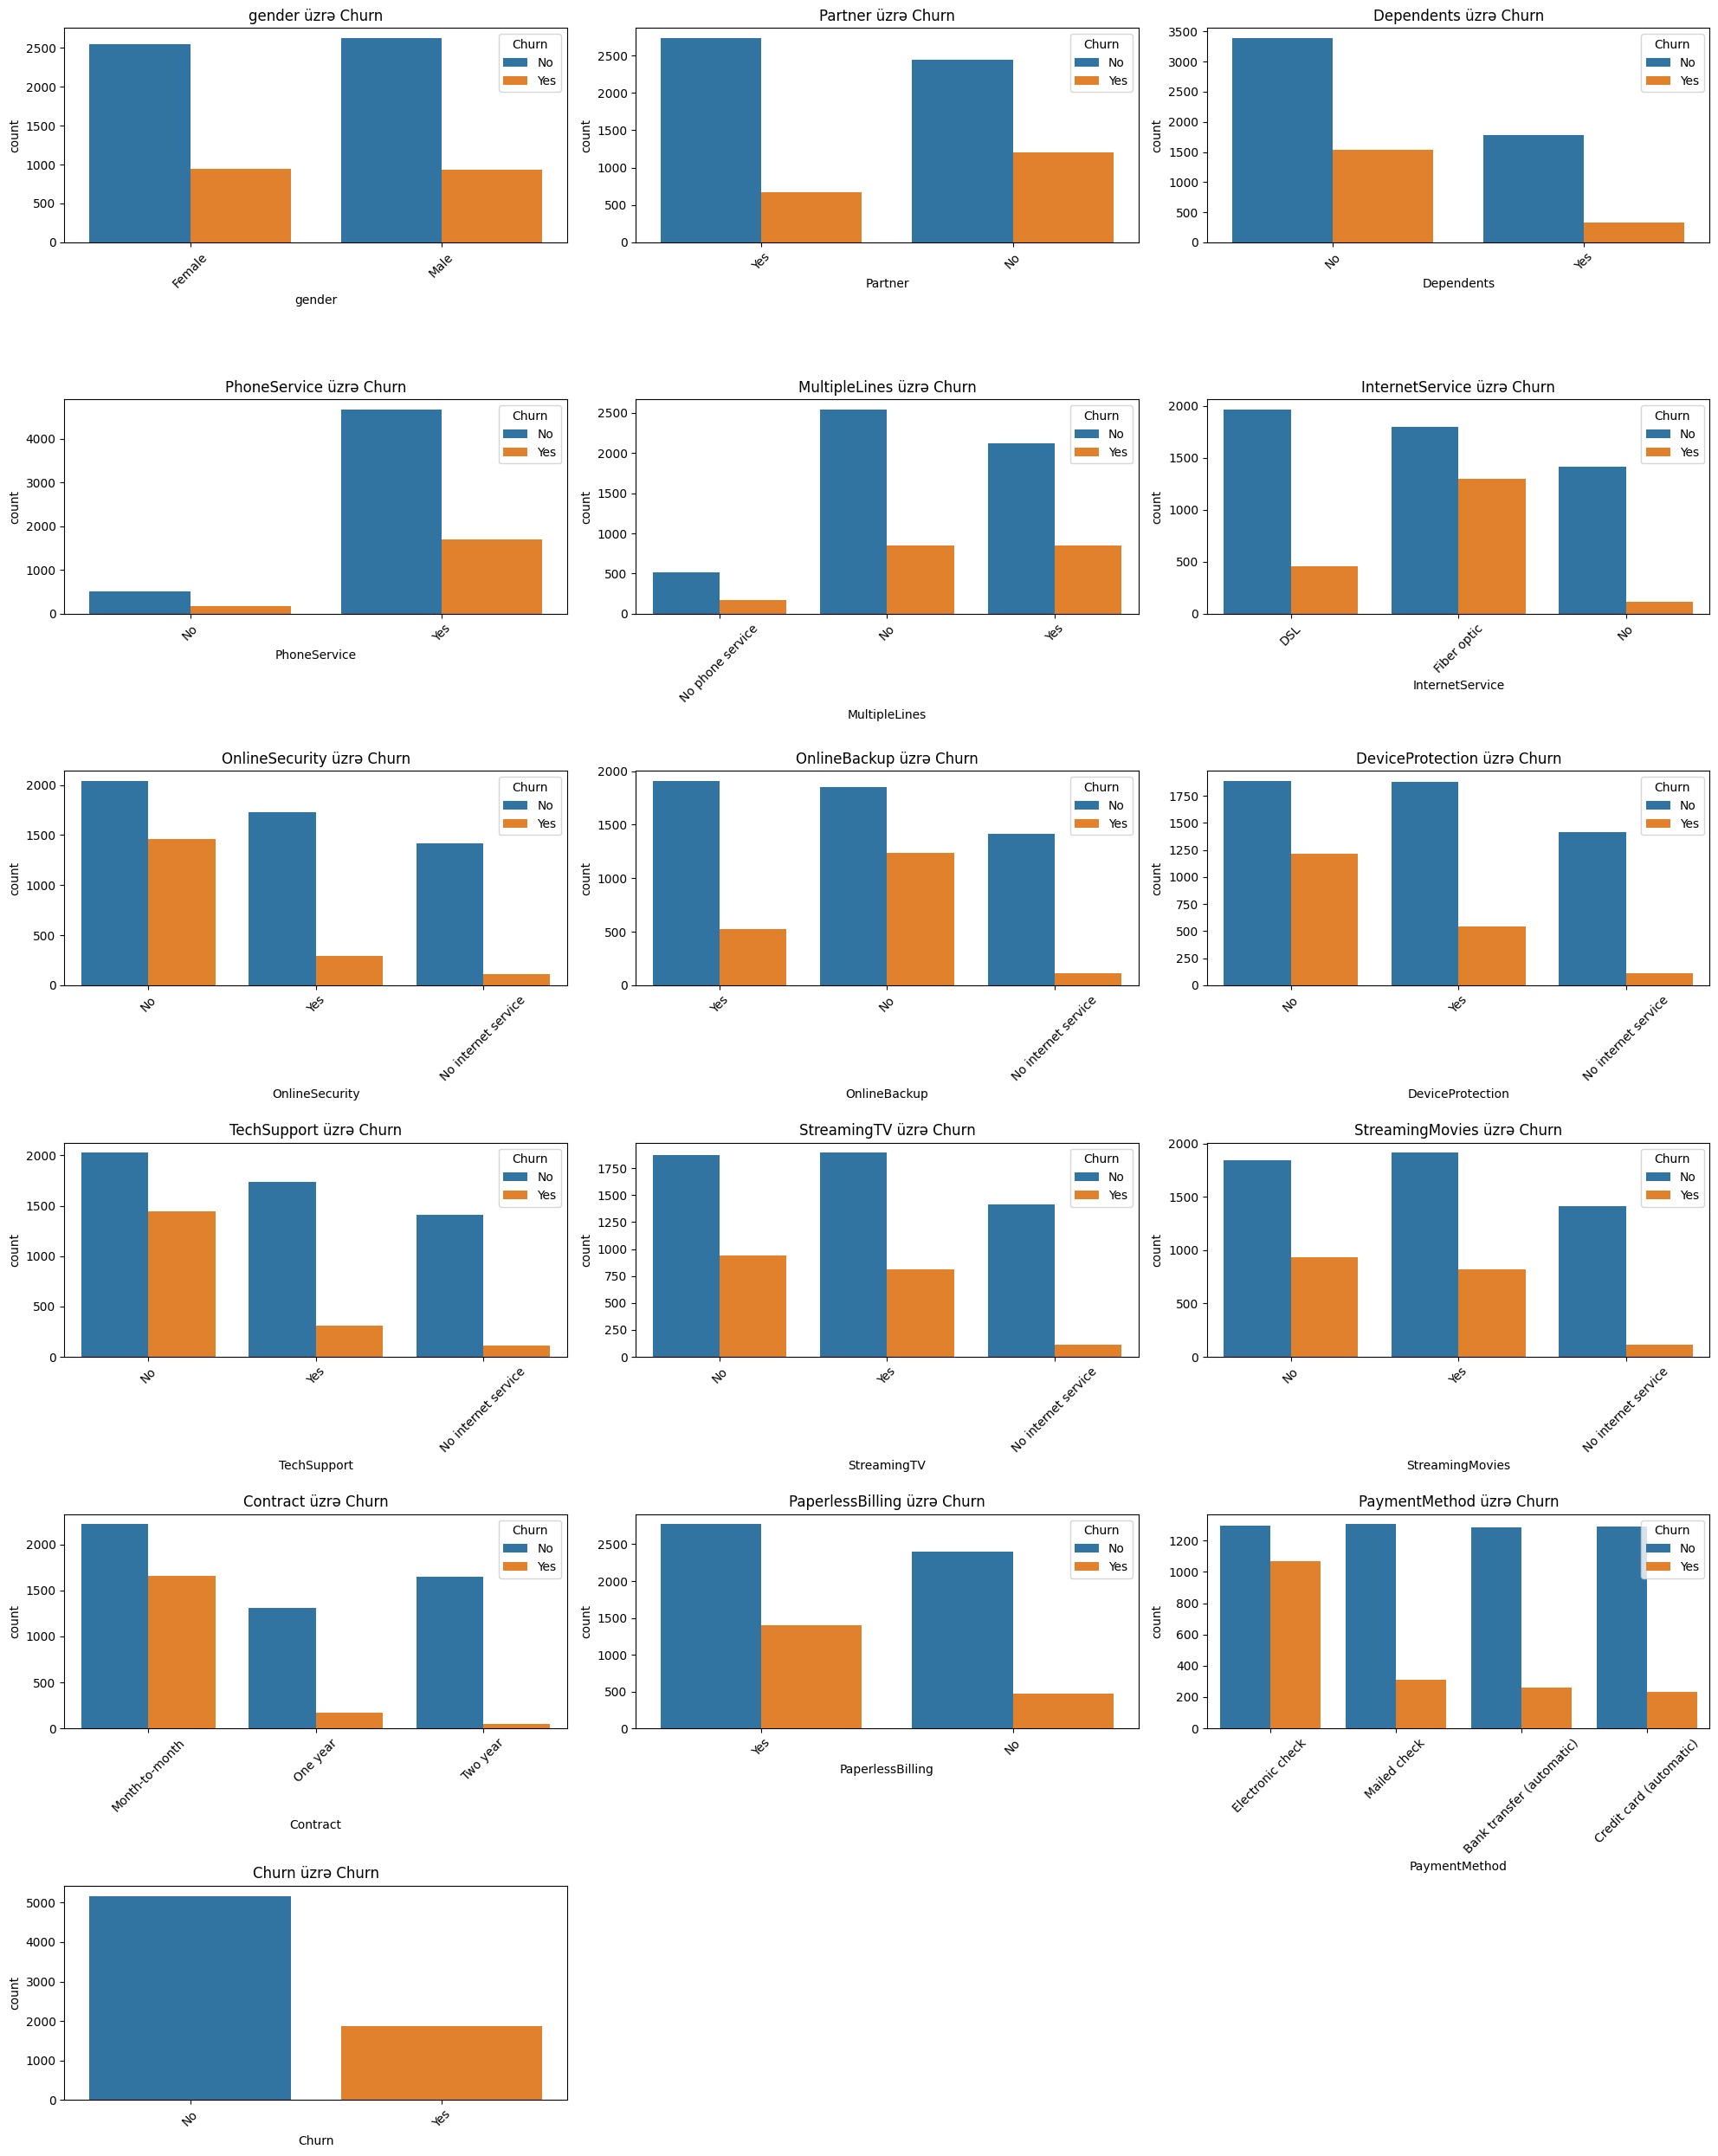

In [20]:
plt.figure(figsize=(20, 25))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(6, 3, i)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} üzrə Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:

print(df.groupby('gender')['Churn'].value_counts(normalize=True))

gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64


In [22]:
df.drop('gender',axis = 1,inplace = True)

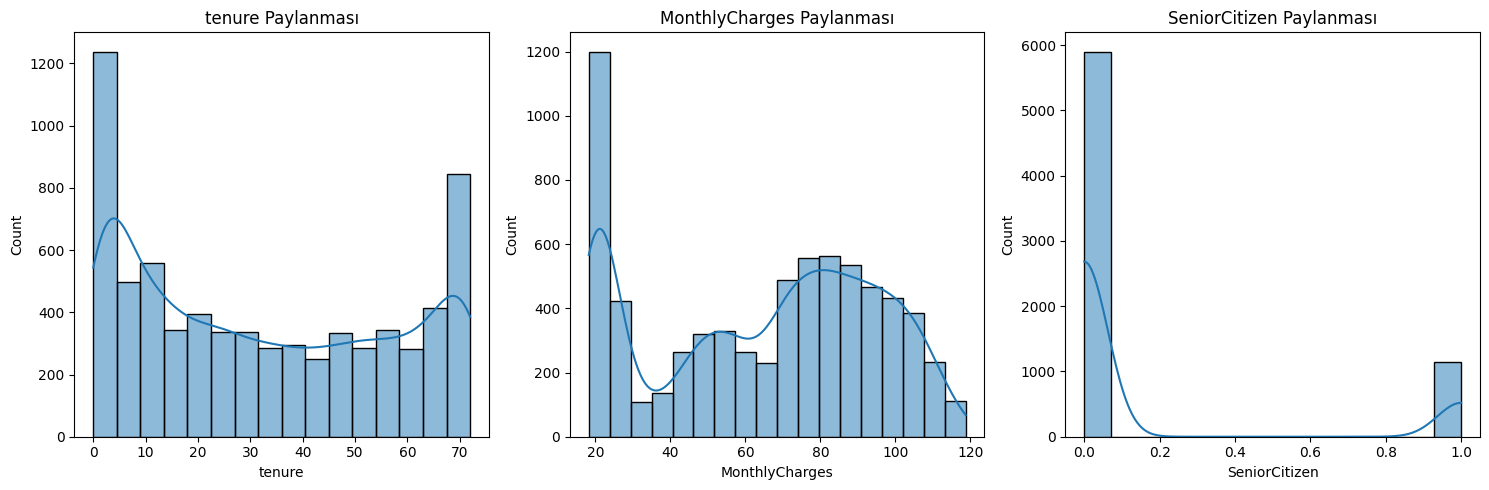

In [23]:
# Ədədi sütunların paylanması
numerical_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True) # kde=True əyri xətti göstərir
    plt.title(f'{col} Paylanması')

plt.tight_layout()
plt.show()

In [24]:


cols = ['tenure', 'MonthlyCharges']


lower = df[cols].quantile(0.01)
upper = df[cols].quantile(0.99)

df[cols] = df[cols].clip(lower=lower, upper=upper, axis=1)

print("Capping uğurla tamamlandı!")

Capping uğurla tamamlandı!


In [25]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [26]:
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [27]:
scaler = StandardScaler()
scaler_cols = ['tenure', 'MonthlyCharges']
df[scaler_cols] = scaler.fit_transform(df[scaler_cols])


In [28]:
X = df.drop('Churn',axis = 1)
Y = df['Churn']

In [29]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 42,test_size = .2 )

In [40]:
model = Sequential([
    Input(shape = (28,)),
    Dense(32,activation = 'relu'),
    Dropout(0.1),
    Dense(16,activation = 'relu'),
    Dropout(0.15),
    Dense(1,activation= 'sigmoid')
])

In [41]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy',Precision(),Recall()])

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
if 'customerID' in X_train.columns:
    X_train = X_train.drop(columns=['customerID'])
    X_test = X_test.drop(columns=['customerID'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight('balanced', classes=np.array([0,1]), y=Y_train)
history = model.fit(
    X_train, Y_train,
    epochs=10,
    validation_data=(X_test, Y_test),
    callbacks=[early_stop],
    class_weight={0: weights[0], 1: weights[1]}
)



Epoch 1/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6732 - loss: 0.5788 - precision_1: 0.4336 - recall_1: 0.7533 - val_accuracy: 0.7509 - val_loss: 0.5064 - val_precision_1: 0.5184 - val_recall_1: 0.8311
Epoch 2/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7359 - loss: 0.5164 - precision_1: 0.5018 - recall_1: 0.7654 - val_accuracy: 0.7537 - val_loss: 0.4811 - val_precision_1: 0.5223 - val_recall_1: 0.8150
Epoch 3/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7410 - loss: 0.5084 - precision_1: 0.5079 - recall_1: 0.7928 - val_accuracy: 0.7594 - val_loss: 0.4751 - val_precision_1: 0.5294 - val_recall_1: 0.8204
Epoch 4/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7442 - loss: 0.5049 - precision_1: 0.5117 - recall_1: 0.8008 - val_accuracy: 0.7523 - val_loss: 0.4830 - val_precision_1: 0.5203 - val_recall_1: 0.8231
Epoch 5/10
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7458 - loss: 0.4996 - precision_1: 0.5139 - recall_1: 0.7908 

In [44]:
print("X_train sütun sayı:", X_train.shape[1])
print("X_test sütun sayı:", X_test.shape[1])

X_train sütun sayı: 28
X_test sütun sayı: 28


In [45]:
loss, accuracy, precision, recall = model.evaluate(X_test, Y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Test Accuracy: 0.7594
Test Precision: 0.5294
Test Recall: 0.8204


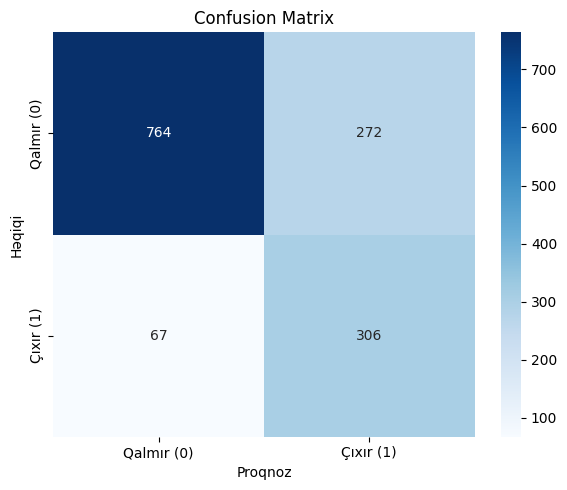

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Qalmır (0)', 'Çıxır (1)'],
            yticklabels=['Qalmır (0)', 'Çıxır (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Proqnoz')
plt.ylabel('Həqiqi')
plt.tight_layout()
plt.show()

In [46]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# 4. Hesabat
print("\n--- DETALLI HESABAT ---")
print(classification_report(Y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- DETALLI HESABAT ---
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [47]:
val_loss, val_acc, val_precision, val_recall = model.evaluate(X_test, Y_test, verbose=0)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)
print("Validation Precision:", val_precision)
print("Validation Recall:", val_recall)

Validation Loss: 0.4751127362251282
Validation Accuracy: 0.7594038248062134
Validation Precision: 0.529411792755127
Validation Recall: 0.8203753232955933


In [48]:
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    # 1. Loss Qrafiki
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss', marker='o')
    plt.plot(history.history[val_loss], label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True) # Qrafiki oxumağı asanlaşdırır
    plt.show()

    # 2. Metrics Qrafiki
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f'Training {train_metric}', marker='o')
    plt.plot(history.history[val_metric], label=f'Validation {val_metric}', marker='o')
    plt.title(f'Training and Validation {train_metric.capitalize()} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(train_metric.capitalize()) # Burada düzəliş etdik
    plt.legend()
    plt.grid(True)
    plt.show()

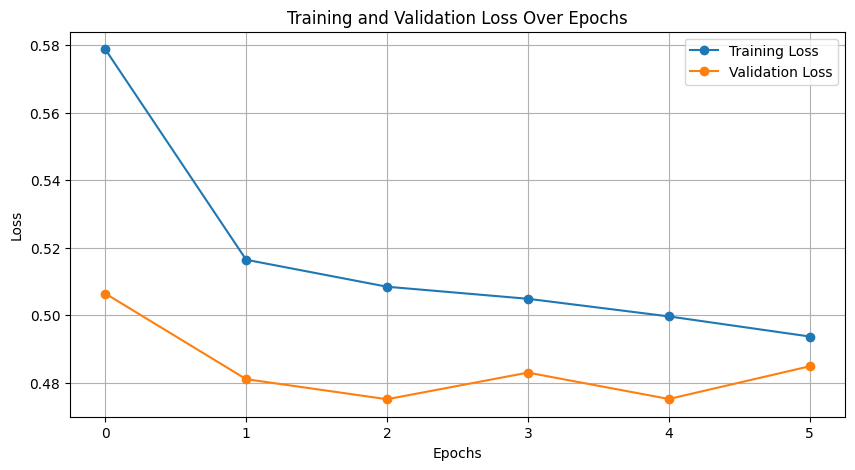

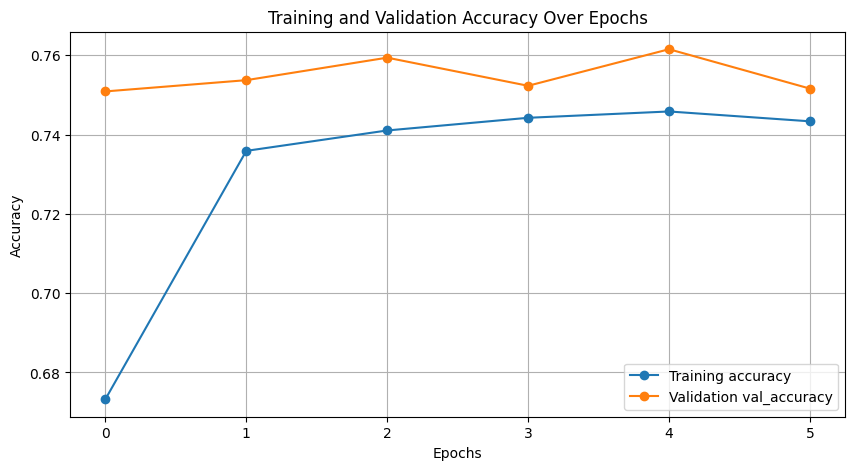

In [49]:
plot_training_history(history)